Doing the image ssl analysis

In [ ]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

import cmasher as cmr

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb
from desi_lowz_funcs import find_objects_nearby
from construct_dwarf_galaxy_catalogs import process_sga_matches
from astropy.table import vstack, join, unique

%load_ext autoreload
%autoreload 2

sample_color_map = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }

import colorsys
import matplotlib.colors as mcolors


def related_contrast_color(hex_color, lighten=True, factor=0.4):
    # Convert HEX → RGB → HSV
    rgb = mcolors.to_rgb(hex_color)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    
    # Adjust brightness (v) or saturation
    if lighten:
        v = min(1, v + factor * (1 - v))
        s = max(0, s - 0.2)  # slightly desaturate
    else:
        v = max(0, v * (1 - factor))
        s = min(1, s + 0.2)
    
    # Back to HEX
    new_rgb = colorsys.hsv_to_rgb(h, s, v)
    return mcolors.to_hex(new_rgb)


In [411]:


def matching_image_paths(target_cat, img_table):
    """
    Returns matched rows between target_cat and img_table based on TARGETID,
    after ensuring img_table has unique TARGETIDs.
    """
    print(f"Initial catalog size = {len(target_cat)}")

    # Ensure img_table has unique TARGETIDs
    img_table_unique = unique(img_table, keys="TARGETID")

    # Perform inner join
    matched_cat = join(
        target_cat,
        img_table_unique,
        keys="TARGETID",
        join_type="inner"
    )

    print(f"Objects with images = {len(matched_cat)}")

    # Optionally, check for any unmatched TARGETIDs
    unmatched_mask = ~np.isin(target_cat["TARGETID"], matched_cat["TARGETID"])
    unmatched_cat = target_cat[unmatched_mask]
    print(f"Objects without images = {len(unmatched_cat)}")

    return matched_cat, unmatched_cat


In [67]:
#we need the image cutout generation different for the TRACTOR_OG vs not as the cutout center is different now!!

filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")

#as that is the regime the data is trained on!
data_cat = data_cat[(data_cat["MAG_Z"] < 20)]

print(f"Size of catalog at z<20 = {len(data_cat)}")

#split by clean and not clean!!
data_cat_og = data_cat[data_cat["PHOTOMETRY_UPDATED"] == False]
data_cat_shreds = data_cat[data_cat["PHOTOMETRY_UPDATED"] == True]

print(f"Size of OG catalog at z<20 = {len(data_cat_og)}")
print(f"Size of shredded catalog at z<20 = {len(data_cat_shreds)}")

#now we need the image paths of these objects!!
temp_clean = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")["TARGETID","IMAGE_PATH","STARDIST_DEG"]
temp_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_shreds_catalog_v4.fits")["TARGETID","IMAGE_PATH","STARDIST_DEG"]
temp_sga = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_desi_SGA_matched_dwarfs_REPROCESS.fits")["TARGETID","IMAGE_PATH","STARDIST_DEG"]

tot_temp = vstack([temp_clean, temp_shred, temp_sga])

tot_temp = unique(tot_temp, keys="TARGETID")

#######

##get the matching image paths for just data_cat_og
data_cat_og_matched, data_cat_og_unmatched = matching_image_paths(data_cat_og, tot_temp)

Size of catalog at z<20 = 193814
Size of OG catalog at z<20 = 177127
Size of shredded catalog at z<20 = 16687
Initial catalog size = 177127
Objects with images = 177127
Objects without images = 0


In [ ]:

# outdir_data = "/pscratch/sd/v/virajvm/redo_photometry_plots/all_good_cutouts"
# ## let us read the file to get ra, dec info     
# clean_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")
# #subselect:
# print(f"Total number = {len(clean_cat)}")

# out = clean_cat

# print("TOTAL NUMBER = ", len(out))

# # out = out #just trying with the first one hundred or so
# #use this to make the file names using objid
# allra = np.array(out["RA"],dtype = object)
# alldec = np.array(out["DEC"],dtype = object)
# allobjids = np.array(out["TARGETID"],dtype = object)
# # allsizes = np.array(out["IMAGE_SIZE_PIX"],dtype = object)
# allsizes = np.full(len(out), 152, dtype=int)
# #we do not need the large 350, just 152 is good enough as for SSL stuff!!

#  ##need to check what fraction of these files exist!!
# file_names = []
# need_inds = []
# n = len(out)

# print("Checking what images already exist!!")
# for k in range(len(allobjids)):
#     file_i = outdir_data + f"/image_tgid_{allobjids[k]:d}_ra_{allra[k]:.3f}_dec_{alldec[k]:.3f}.fits"  
#     if os.path.exists(file_i):
#         pass
#     else:
#         file_names.append(file_i)
#         need_inds.append(k)

#     # log every 100 iterations
#     if (k + 1) % 10000 == 0 or (k + 1) == n:
#         print(f"Processed {k+1}/{n} ({(k+1)/n:.1%})")

# need_inds = np.array(need_inds)

# print(f"Need to download {len(need_inds)}/{len(allra)} images!")

# allra = allra[need_inds]
# alldec = alldec[need_inds]
# allobjids = allobjids[need_inds]
# allsizes = allsizes[need_inds]


# ## we need to get the information now 
# jpegfiles = np.array(file_names, dtype = object)

Download the rest of the images!!

In [40]:
# from desi_lowz_funcs import save_cutouts
# import requests

# def save_cutouts(ra,dec,img_path,session, size=350, timeout = 120):
#     url_prefix = 'https://www.legacysurvey.org/viewer/'
    
#     url = url_prefix + f'cutout.fits?ra={ra}&dec={dec}&size=%s&'%size

#     url += 'layer=ls-dr9&pixscale=0.262&bands=grz'

#     try:
#         resp = session.get(url, timeout=timeout)
#         resp.raise_for_status()  # Raise error for bad status codes
#         # Save the FITS file
#         with open(img_path, "wb") as f:
#             f.write(resp.content)
    
#         #load the wcs and image data
#         # img_data = fits.open(img_path)
#         # data_arr = img_data[0].data
#         # wcs = WCS(fits.getheader( img_path ))
#     except:
#         print("getting coadd image data failed!")
#         print(url)
    
#     return

In [39]:
# session = requests.Session()

# for i in trange(len(allra)):
#     save_cutouts(allra[i],alldec[i], jpegfiles[i], session, size=152)

## IMAGE UMAP PLOTS!!

Note that these are only for objects that are at z<20

In [3]:
umaps_dwarfs = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/umap/total_umap_embedding_2d.npy")


In [6]:
rmags_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_rmags_arr.npy")
gmags_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_gmags_arr.npy")

zreds_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_zreds_arr.npy")
logm_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_mstar_arr.npy")
stardist_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_stardist_arr.npy")

# tgid_vals = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_targetids_arr.npy")


In [7]:
gr_vals = gmags_vals - rmags_vals

In [5]:
umaps_dwarfs.shape

(193804, 2)

In [69]:
def make_umap_plot(fig, ax, umap_coords, quant, 
                  n_bins=150, limits = None,
                  cmap = cmr.chroma,scatter=False, 
                  cb_label = r"$\log\mathrm{[OIII]}/\mathrm{H}\beta$", cb_size = 12, cb_padding=4, cb_pos = [0,1,0.33,0.02]):

    embedding_x = umap_coords[:,0]
    embedding_y = umap_coords[:,1]
    
    counts, _, _ = np.histogram2d(embedding_x, embedding_y, bins=n_bins)
    
    hist_2, xedges, yedges = np.histogram2d(embedding_x, embedding_y, bins=n_bins, weights = quant) 

    averaged_2 = hist_2/counts

    if limits is None:
        vmin_2 = np.percentile(quant, 2.3 )
        vmax_2 = np.percentile(quant, 97.7)
    else:
        vmin_2 = limits[0]
        vmax_2 = limits[1]
        
    print(f"Plotting limits = {vmin_2}, {vmax_2}")

    if scatter:
        samp_freq = 10
        sc = ax.scatter(embedding_x[::samp_freq], embedding_y[::samp_freq],c= quant[::samp_freq], cmap=cmr.cosmic,vmin=vmin_2,vmax=vmax_2,s=0.5,rasterized=True)

    else:
        sc = ax.pcolormesh(xedges, yedges, averaged_2.T, shading='auto', cmap=cmap,vmin=vmin_2,vmax=vmax_2,rasterized=True)

     # --- Colorbar above the axes, centered ---
    # get the axis position in figure coordinates

    # compute left position so that colorbar is centered
    
    # create a new axes for colorbar
    cax = fig.add_axes(cb_pos)
    cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('bottom')
    cb.set_label(cb_label, fontsize=cb_size, labelpad=cb_padding)
    
    ax.set_xlim([-10,15])
    ax.set_ylim([-3,17.5])
    
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all spines (the box around the plot)
    for spine in ax.spines.values():
        spine.set_visible(False)
        

    return


In [70]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define colormap
cmap_r2b = LinearSegmentedColormap.from_list(
    "red_to_blue",
    ["blue", "red"]
)

/tmp/ipykernel_1578787/1434062963.py:13: RuntimeWarning: invalid value encountered in true_divide
  averaged_2 = hist_2/counts


Plotting limits = 0.010692600616253913, 0.10600813482701776
Plotting limits = 16.761228200912477, 20.15217310142517
Plotting limits = 0.2, 0.6


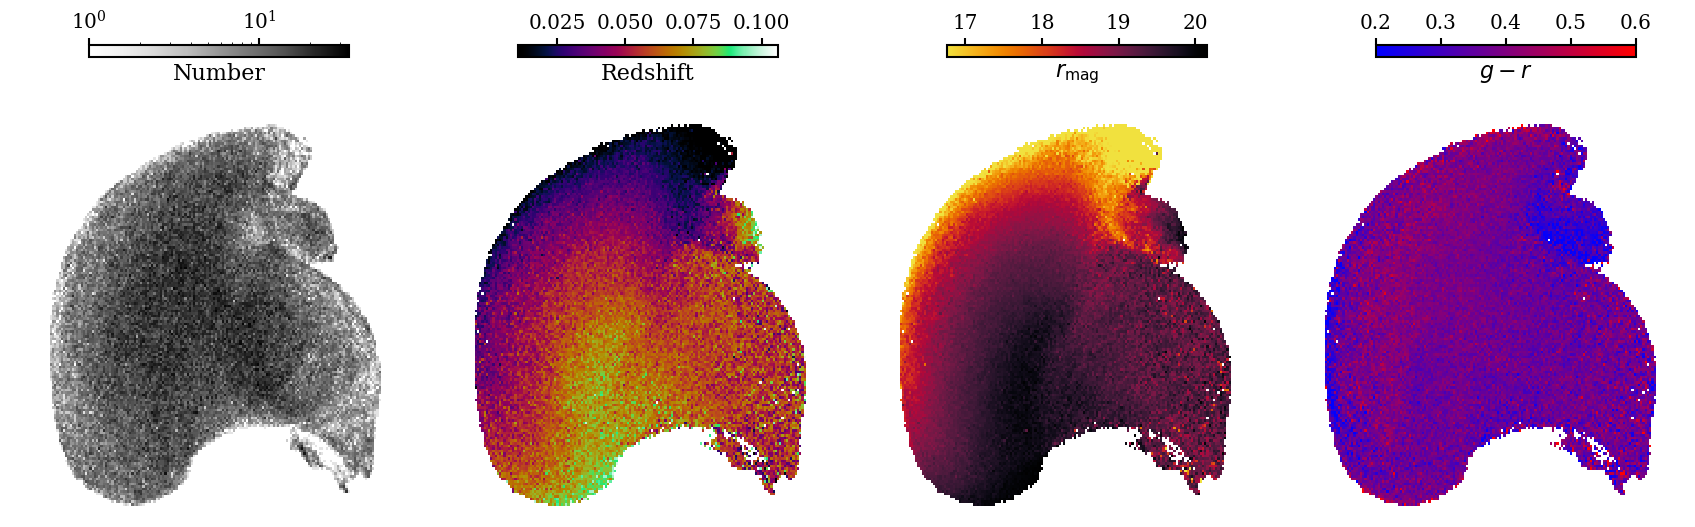

In [74]:
fig,ax = make_subplots(ncol=4, nrow=1,plot_size=4,return_fig=True,col_spacing = 0.25)

nbins = 150

bar_size = 0.2
offset_bar = 0.33

cb_size = 16
cb_height = 0.95

#let us make the density one here!!

def get_edges_counts(umap_coords):
    n_bins = 150
    hist, xedges, yedges = np.histogram2d(umap_coords[:,0], umap_coords[:,1], bins=n_bins) 
    # Step 3: Calculate the number of points in each bin
    counts, _, _ = np.histogram2d(umap_coords[:,0], umap_coords[:,1], bins=n_bins)
    return xedges, yedges, counts

xedges, yedges, counts = get_edges_counts(umaps_dwarfs)

sc = ax[0].pcolormesh(xedges, yedges, counts.T, shading='auto', cmap='Greys',norm=LogNorm(),rasterized=True)

###
# create a new axes for colorbar
cax = fig.add_axes([0.08,cb_height,bar_size,0.02])
cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('bottom')
cb.set_label("Number", fontsize=cb_size, labelpad=4)

ax[0].set_xlim([-10,15])
ax[0].set_ylim([-3,17.5])

ax[0].set_xticks([])
ax[0].set_yticks([])

# Remove all spines (the box around the plot)
for spine in ax[0].spines.values():
    spine.set_visible(False)
    
####


make_umap_plot(fig, ax[1], umaps_dwarfs, zreds_vals, 
                  n_bins=150, limits = None,
                  cmap = cmr.chroma,scatter=False, 
                  cb_label = r"Redshift", cb_size = cb_size, cb_padding=4, cb_pos = [0.08+offset_bar,cb_height,bar_size,0.02])

make_umap_plot(fig, ax[2], umaps_dwarfs, rmags_vals, 
                  n_bins=150, limits = None,
                  cmap = cmr.ember_r,scatter=False, 
                  cb_label = r"$r_{\rm mag}$", cb_size = cb_size, cb_padding=4, cb_pos = [0.08+2*offset_bar,cb_height,bar_size,0.02])


make_umap_plot(fig, ax[3], umaps_dwarfs, gr_vals, 
                  n_bins=150, limits = [0.2,0.6],
                  cmap = cmap_r2b,scatter=False, 
                  cb_label = r"$g-r$", cb_size = cb_size, cb_padding=4, cb_pos = [0.08+3*offset_bar,cb_height,bar_size,0.02])


plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_image_sample.pdf",bbox_inches="tight")
plt.show()



## Could we test how informative embeddings are for redshift estimation ?

In [695]:
# we can take random galaxy and its redshift, and then take random 50 other galaxies, and then see the median difference
#there should be basically no correlation, then we can find the 50 nearest galaxies in rmag, g-r space and see if that 
#helps with redshift, and then finally we do 50 nearest in the latent space vector and see how better the redshift prediction is
## .. .




In [130]:
tgids_arr = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/dwarf_dr1/total_targetids_arr.npy")

print(tgids_arr.shape)


sim_scores = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/similarity_search_magb/all_similarity_scores_total.npy")
sim_tgids = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/similarity_search_magb/all_similarity_targetids_total.npy")

print(sim_scores.shape, sim_tgids.shape)

##note that the targetids in this array are not cleaned for dwarf_maskbit=0
#the first targetid in the sim_tgids is the targetid that is being used to do the similarity search

(193804, 50) (193804, 50)


In [140]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")

#as that is the regime the data is trained on!
data_cat = data_cat[(data_cat["MAG_Z"] < 20) & (data_cat["DWARF_MASKBIT"] == 0)]


In [143]:
data_cat["TARGETID"].data[:4]

array([39627066986994125, 39627067007963313, 39627072187928583,
       39627072192121852])

In [499]:
from sklearn.preprocessing import StandardScaler

targetid_to_idx = {tid: i for i, tid in enumerate(data_cat["TARGETID"])}

def get_similar_objects(targetid, X_scaled, nn, targetid_to_idx):
    idx = targetid_to_idx[targetid]

    x0 = X_scaled[idx].reshape(1, -1)
    distances, indices = nn.kneighbors(x0)

    # Remove self-match if desired
    mask = indices[0] != idx

    return {
        "TARGETID": data_cat["TARGETID"][indices[0][mask]],
        "DIST": distances[0][mask]
    }

def get_nn_tree(data_cat, complexity):
    
    # catalog arrays
    # shape (N,)
    rmag = data_cat["MAG_R"].data
    gr   = data_cat["MAG_G"].data - data_cat["MAG_R"].data
    shape_r = data_cat["R50_R"].data

    if complexity==2:
        X = np.vstack([rmag, shape_r]).T
    if complexity==3:
        X = np.vstack([rmag, shape_r, gr]).T

    print(X.shape)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    cov = np.cov(X_scaled, rowvar=False)
    inv_cov = np.linalg.inv(cov)
    
    from sklearn.neighbors import NearestNeighbors
    
    nn = NearestNeighbors(
        n_neighbors=20,
        metric="mahalanobis",
        metric_params={"VI": inv_cov}
    )
    nn.fit(X_scaled)

    return nn, X_scaled


nn_2, X_scaled_2 = get_nn_tree(data_cat, 2)
nn_3, X_scaled_3 = get_nn_tree(data_cat, 3)


(185775, 2)
(185775, 3)


In [501]:

def get_zred_statistics(tgid_i = 39627066986994125):
    '''
    Function that will study how useful it is to use SSL framework for estimating redshift
    '''

    print(tgid_i)
    sim_scores_i = sim_scores[sim_tgids[:,0] == tgid_i]

    sim_tgids_i = sim_tgids[sim_tgids[:,0] == tgid_i]

    #get the top 50 latent vectors and >0.75 score
    sim_tgids_i = sim_tgids_i[sim_scores_i > 0.75][1:]
    cat_mask = np.isin(data_cat["TARGETID"].data, sim_tgids_i )

    ##find the most similar objects in photometric space
    photo_sims = get_similar_objects(
        targetid=tgid_i,
        X_scaled=X_scaled,
        nn=nn,
        targetid_to_idx=targetid_to_idx)
    
    photo_sim_mask = np.isin(data_cat["TARGETID"].data, photo_sims["TARGETID"].data[1:])

    #draw a random sample of 50 from the entire cat
    rnd_inds = np.random.randint(0, len(data_cat), size=50)
    rnd_zreds = data_cat["Z"].data[rnd_inds]

    plt.figure(figsize = (5,5))
    plt.hist(data_cat[cat_mask]["Z"],density=True,color = "darkorange")
    plt.hist(data_cat[photo_sim_mask]["Z"],density=True,color = "purple",histtype="step",lw=2)
    
    # plt.hist(rnd_zreds,density=True,color = "grey",histtype="step",lw=3)
    
    plt.axvline(x=data_cat[ data_cat["TARGETID"] == tgid_i ]["Z"].data,color="k",lw=8,alpha=0.5)
    
    plt.axvline(x=np.median(rnd_zreds),color="grey",ls="--")
    plt.axvline(x=np.median(data_cat[cat_mask]["Z"]),color="firebrick",ls="--")
    plt.axvline(x=np.median(data_cat[photo_sim_mask]["Z"]),color="purple",ls="--")
    
    plt.xlim([0,0.15])

    plt.show()

    return
        

In [502]:
def predict_z_ssl(tgid, data_cat, sim_tgids, sim_scores,
                  score_cut=0.75, kmax=50):
    """
    Predict redshift using SSL cosine neighbors.
    """
    mask = (sim_tgids[:, 0] == tgid)
    #remove self
    tgids_i = sim_tgids[mask][0][1:]
    scores_i = sim_scores[mask][0][1:]

    good = scores_i > score_cut
    tgids_i = tgids_i[good][:kmax]

    if len(tgids_i) < kmax:
        return np.nan

    zvals = data_cat["Z"][np.isin(data_cat["TARGETID"].data, tgids_i)]
    return np.median(zvals)


def predict_z_photo(tgid, data_cat, nn, X_scaled, targetid_to_idx,
                    dmax=2.0, kmax=50):
    """
    Predict redshift using photometric nearest neighbors.
    """
    idx = targetid_to_idx[tgid]
    x0 = X_scaled[idx].reshape(1, -1)

    dists, inds = nn.kneighbors(x0, n_neighbors=kmax+1)

    # remove self
    dists = dists[0][1:]
    inds = inds[0][1:]

    good = dists < dmax
    inds = inds[good]

    if len(inds) < kmax:
        return np.nan

    return np.median(data_cat["Z"][inds])

def predict_z_random(data_cat, k=50):
    inds = np.random.randint(0, len(data_cat), size=k)
    return np.median(data_cat["Z"][inds])



In [503]:
from tqdm.notebook import trange

def run_redshift_prediction_experiment(
    data_cat,
    sim_tgids,
    sim_scores,
    targetid_to_idx,
    score_cut=0.8,
    dmax=2.0,
    kmax=50):
    
    results = []

    for i in trange(len(data_cat)):
        tgid = data_cat["TARGETID"][i]
        z_true = data_cat["Z"][i]
        rmag = data_cat["MAG_R"][i]

        z_ssl = predict_z_ssl(
            tgid, data_cat, sim_tgids, sim_scores,
            score_cut=score_cut, kmax=20
        )

        z_photo_2 = predict_z_photo(
            tgid, data_cat, nn_2, X_scaled_2, targetid_to_idx,
            dmax=dmax, kmax=20
        )

        z_photo_3 = predict_z_photo(
            tgid, data_cat, nn_3, X_scaled_3, targetid_to_idx,
            dmax=dmax, kmax=20
        )


        results.append( (z_true, z_ssl, z_photo_2, z_photo_3, rmag)  )

    return np.array(
        results,
        dtype=[("z_true", float),
               ("z_ssl", float),
               ("z_photo_2", float),
               ("z_photo_3", float),               
               ("rmag", float)]
    )


In [504]:
results = run_redshift_prediction_experiment(
    data_cat,
    sim_tgids,
    sim_scores,
    targetid_to_idx,
    score_cut=0.8,
    dmax=2.0,
    kmax=50)

  0%|          | 0/185775 [00:00<?, ?it/s]

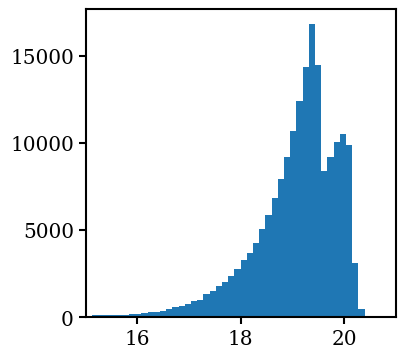

In [567]:
plt.figure(figsize = (4,4))
plt.hist(results["rmag"],range=(15,21),bins=50)
plt.xlim([15,21])
plt.show()

In [568]:
from scipy.stats import median_abs_deviation
import numpy as np

def sigma_nmad(z_true, z_pred):
    mask = np.isfinite(z_pred)
    dz = z_pred[mask] - z_true[mask]
    return 1.48 * np.median( np.abs(dz - np.median(dz)) / (1 + z_true[mask]) )

    
def binned_sigma_nmad(z_true, z_pred, col, bins):
    centers = 0.5 * (bins[:-1] + bins[1:])
    sig = np.zeros(len(centers))

    for i in range(len(centers)):
        m = (results[col] >= bins[i]) & (results[col] < bins[i+1])
        if np.sum(m) > 20:
            sig[i] = sigma_nmad(z_true[m], z_pred[m])
        else:
            sig[i] = np.nan

    return centers, sig


def binned_stat(x, y, bins):
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    med = np.zeros(len(bin_centers))
    p16 = np.zeros(len(bin_centers))
    p84 = np.zeros(len(bin_centers))

    for i in range(len(bin_centers)):
        m = (x >= bins[i]) & (x < bins[i+1]) & np.isfinite(y)
        if np.sum(m) > 10:
            med[i] = np.median(y[m])
            p16[i] = np.percentile(y[m], 16)
            p84[i] = np.percentile(y[m], 84)
        else:
            med[i] = np.nan
            p16[i] = np.nan
            p84[i] = np.nan

    return bin_centers, med, p16, p84


In [570]:
z_true  = results["z_true"]
z_ssl   = results["z_ssl"]
z_photo_2 = results["z_photo_2"]
z_photo_3 = results["z_photo_3"]
rmag    = results["rmag"]

In [480]:
rmag_bins = np.arange(15,20.5,0.25)

In [571]:
bc, sig_ssl   = binned_sigma_nmad(z_true, z_ssl, "rmag", rmag_bins )
bc, sig_photo_2   = binned_sigma_nmad(z_true, z_photo_2, "rmag", rmag_bins )
bc, sig_photo_3   = binned_sigma_nmad(z_true, z_photo_3, "rmag", rmag_bins )



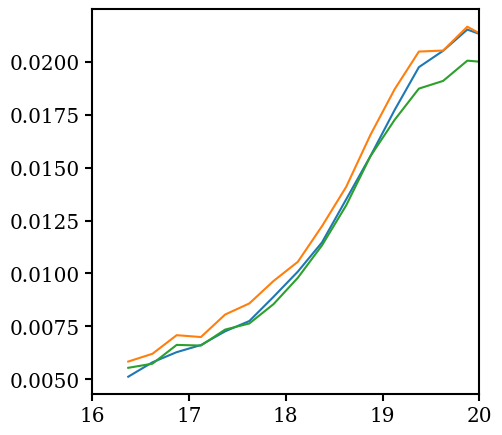

In [573]:
plt.figure(figsize = (5,5))
plt.plot(bc,sig_ssl)
plt.plot(bc,sig_photo_2)
plt.plot(bc,sig_photo_3)
plt.xlim([16,20])
plt.show()

Note: this exercise does not make much sense as we are already applying a cut on stellar mass, so am working with a rather limited sample space ... 

In [417]:
rmag_mb = (results["rmag"] < 19) 

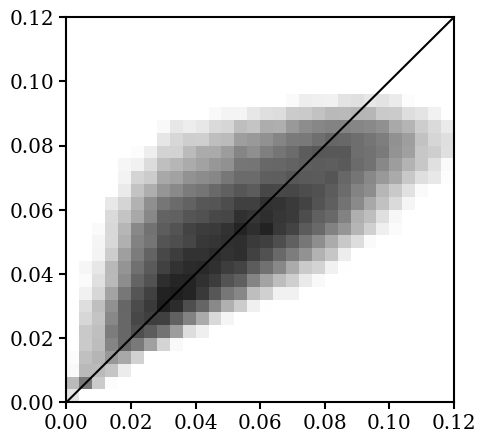

In [449]:
bins=30

plt.figure(figsize = (5,5))
plt.hist2d(results["z_true"], results["z_ssl"],range=((0,0.12),(0,0.12)),bins=bins,cmap="Greys",norm=LogNorm(vmin=50,vmax=2000) )
plt.xlim([0,0.12])
plt.ylim([0,0.12])
plt.plot([0,0.12],[0,0.12],color="k")
plt.show()


## Make a magnitude vs. stellar mass plot 

In [837]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat_all = Table.read(filename, hdu="MAIN")

data_cat_all = data_cat_all[data_cat_all["DWARF_MASKBIT"] == 0]

In [613]:
mstar_vals = data_cat_all["LOG_MSTAR_M24"].data

In [577]:
mstar_mask = (mstar_vals > 7.5) & (mstar_vals < 8)

In [578]:
### draw a random sample between each 1 mag bin
rmag_bins = np.arange(16.25,21.5,0.25)

In [580]:
for i in range(len(rmag_bins)-1):
    rmag_low = rmag_bins[i]
    rmag_hi = rmag_bins[i+1]
    rmag_mask = (data_cat_all["MAG_R"].data > rmag_low) & (data_cat_all["MAG_R"].data < rmag_hi)
    sample = data_cat_all[mstar_mask & rmag_mask]
    #choose a random object
    if len(sample) == 0:
        print(99)
    else:
        print(sample["TARGETID"][0])
    

39627874986101068
39627357580956928
39627369127877300
39627380708344530
39627357585148428
39627491849013923
39627374865685884
39627368674886520
39627369245314455
39627363515892690
39627375046036002
39627339692251081
39627340271065922
39632930615593487
39627329424590755
39627345413284126
39627770178831857
2705974242574336
2705992089337856
39632936261124735


In [ ]:
39627403265312105?? where does this lie in the spectral umap space


39627883991269971 <- this sort of has this blue very sharp slope downward .. seems like reduction issue 
## can we identify a flag to filter by suspicious redshifts ... 2

In [614]:
from desi_lowz_funcs import save_jpg
import matplotlib.image as mpimg
import requests

In [667]:
# Example bins
rmag_bins = rmag_bins = np.arange(16.25,20.75,0.25)
print(len(rmag_bins))
logm_bins = np.arange(6,9.5,0.5) 

mstar_vals = data_cat_all["LOG_MSTAR_M24"].data
rmag_vals = data_cat_all["MAG_R"].data

image_size = 115
save_path = "/pscratch/sd/v/virajvm/trash/desi_imgs"

session = requests.Session()

def swap(new_tgid):
    ra_i = data_cat_all[data_cat_all["TARGETID"] == new_tgid]["RA"][0]
    dec_i = data_cat_all[data_cat_all["TARGETID"] == new_tgid]["DEC"][0]
    return ra_i, dec_i, new_tgid
    
# Dummy images
images = {}
counts = {}
for i in range(len(rmag_bins)-1):
    for j in range(len(logm_bins)-1):
        logm_mask = (mstar_vals > logm_bins[j]) & (mstar_vals < logm_bins[j+1])
        rmag_mask = (rmag_vals > rmag_bins[i]) & (rmag_vals < rmag_bins[i+1])

        cat_i = data_cat_all[rmag_mask & logm_mask]

        if len(cat_i) == 0:
            img = None #np.ones((image_size,image_size))
        else:    
            ra_i = cat_i["RA"].data[0]
            dec_i = cat_i["DEC"].data[0]
            tgid_i = cat_i["TARGETID"].data[0]

            if tgid_i == 39627600477290925:
                ra_i, dec_i, tgid_i = swap(39628516483926392)
            if tgid_i == 39627403265312105:
                ra_i, dec_i, tgid_i = swap(39627715183120706)    
            if tgid_i == 39627824155330825:
                ra_i, dec_i, tgid_i = swap(39628268134994442)    
            if tgid_i == 39627672900340781:
                ra_i, dec_i, tgid_i = swap(39627769608406676)    
            
            img_path = save_path + f"/img_{tgid_i}.jpg"
            #check if img exists first
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
            else:
                save_jpg(ra_i,dec_i,img_path,session, size=image_size)
                
                img = mpimg.imread(img_path)
        
        images[(i,j)] = img
        counts[(i,j)] = len(cat_i)

18


In [691]:
def plot_tight_image_grid(images, counts, rmag_bins, logm_bins,fontsize = 30):
    Nx = len(rmag_bins) - 1  # 15
    Ny = len(logm_bins) - 1  # 6

    fig, axes = plt.subplots(Ny, Nx, figsize=(int(Nx*2), int(Ny*2)))
    plt.subplots_adjust(wspace=0.015, hspace=0.015)  # remove space between subplots

    for j in range(Ny):
        for i in range(Nx):
            ax = axes[Ny - 1 - j, i]  # invert y so low mass is bottom
            img = images.get((i, j))

            if img is not None:
                ax.imshow(
                    img,
                    aspect='equal',
                    rasterized=True
                )

            ax.set_xticks([])
            ax.set_yticks([])
            ctsi = counts[(i,j)]
            if ctsi == 0:
                color_i ="k"
            else:
                color_i ="white"
                
            ax.text(0.925,0.85,ctsi, color=color_i, fontsize=fontsize-15,transform=ax.transAxes,ha="right",va="center")

            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Add axis labels only at edges
            if j == 0 and i != Nx-1:  # bottom row: show rmag
                ax.set_xlabel(f"{rmag_bins[i+1]:.2f}", fontsize=fontsize-12.5, rotation=0, labelpad=5,color = "k")
                ax.xaxis.set_label_coords(1, -0.05)
            
            if i == 0:  # left column: show logM*
                ax.set_ylabel(f"{logm_bins[j]:.2f}", fontsize=fontsize-12.5, rotation=0, color="k")
                ax.yaxis.set_label_coords(-0.2, 0)

    # Add a big text label for the quantities being binned
    fig.text(0.5, 0.05, r"$r_{\rm mag}$", ha='center', va='center', fontsize=fontsize-5+2)
    fig.text(0.1, 0.5, r"$\log_{10} M_{\bigstar}$", ha='center', va='center', rotation='vertical', fontsize=fontsize-5)

    return fig, axes


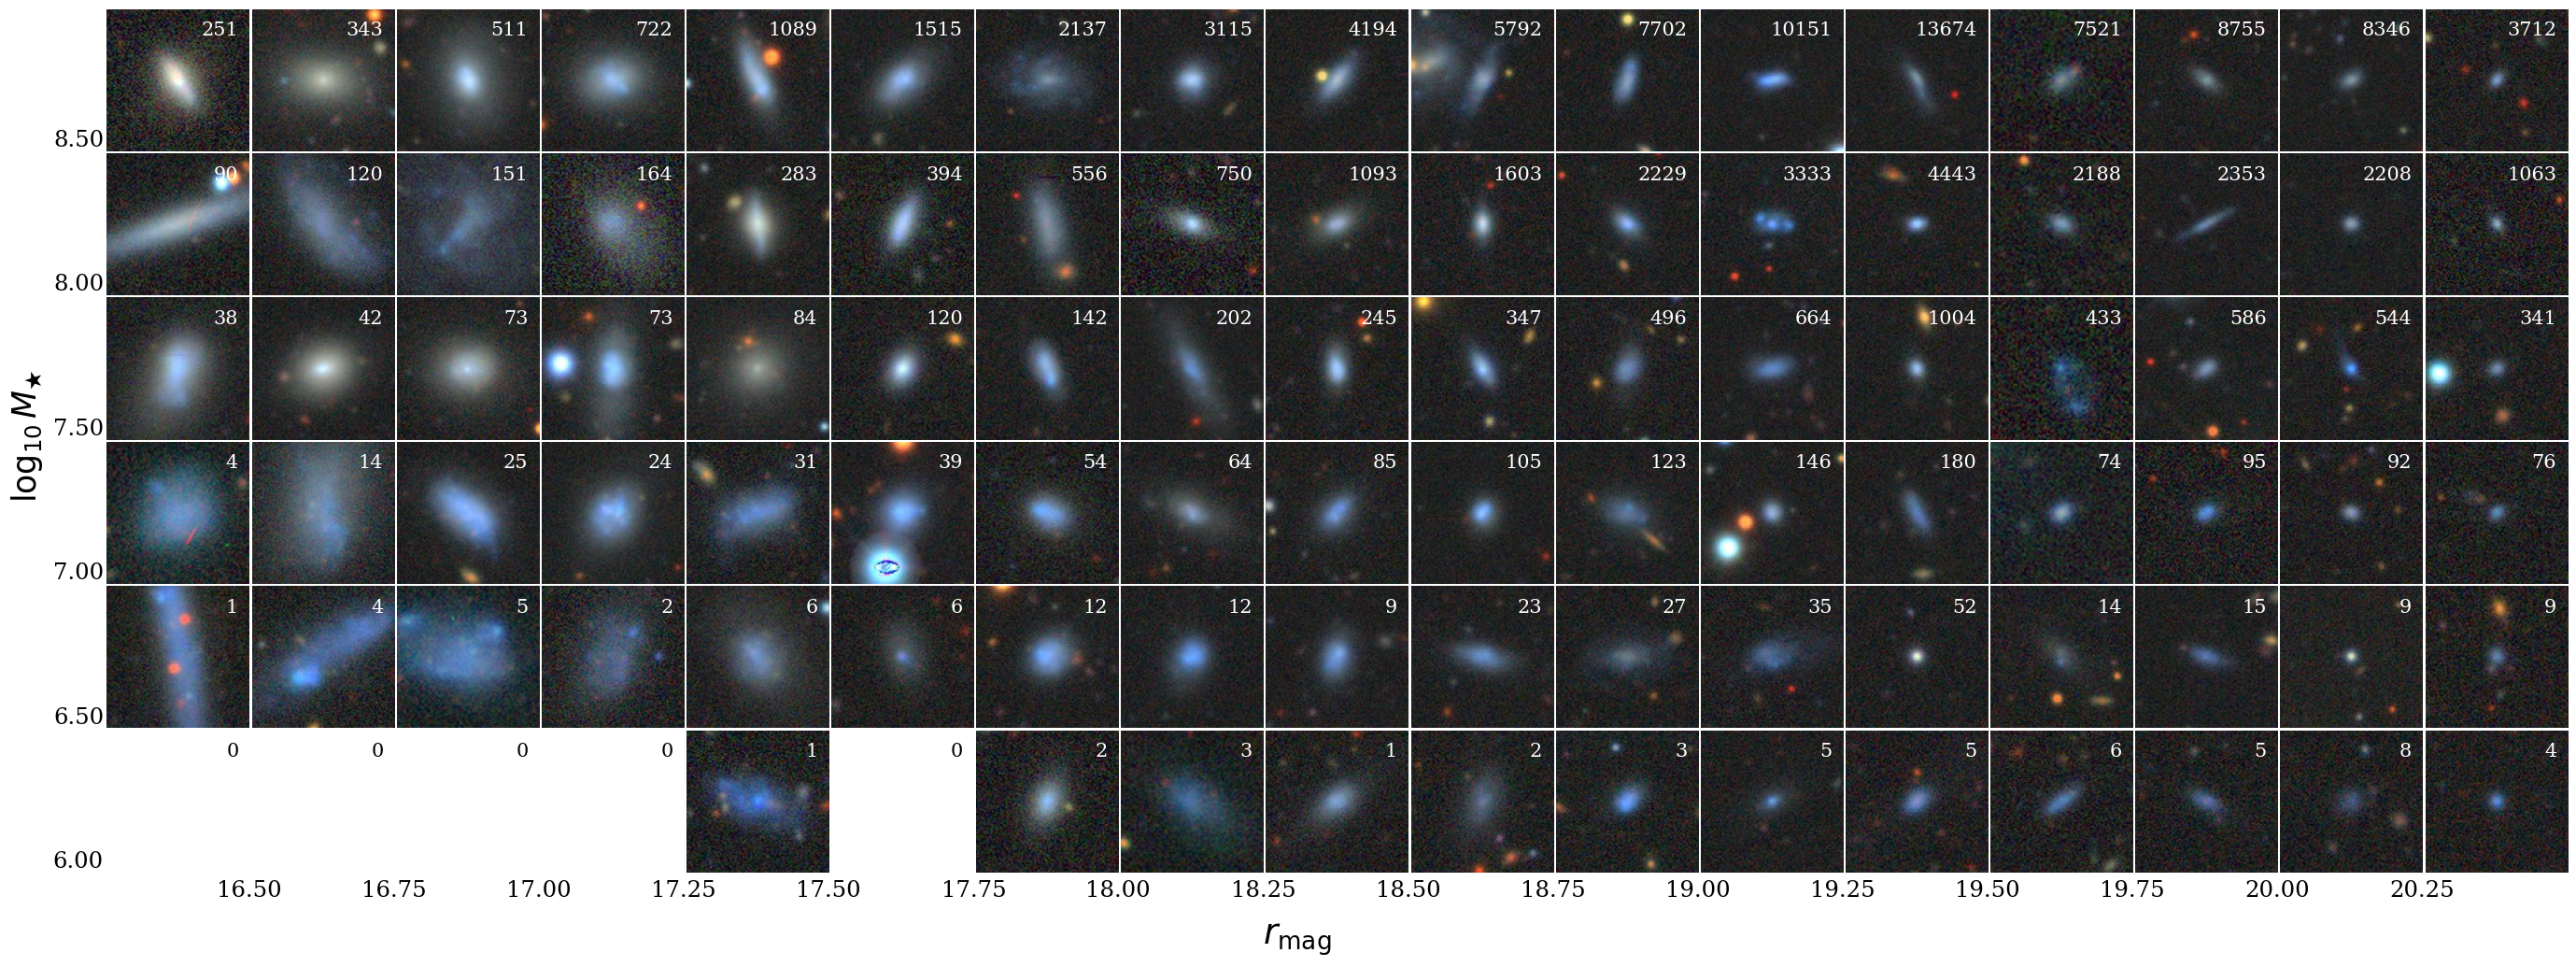

In [692]:

fig,ax = plot_tight_image_grid(images, counts, rmag_bins, logm_bins)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_imgs_grid.pdf",bbox_inches="tight")

plt.show()


### Making a plot showing the similarity search abilities

In [805]:
tgids_eg = [39627954128421629, 39627631053769626, 39627980753869373,  39627884041601442 ]

In [806]:
sim_scores = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/similarity_search_magb/all_similarity_scores_total.npy")
sim_tgids = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/similarity_search_magb/all_similarity_targetids_total.npy")

print(sim_scores.shape, sim_tgids.shape)

##note that the targetids in this array are not cleaned for dwarf_maskbit=0
#the first targetid in the sim_tgids is the targetid that is being used to do the similarity search

(193804, 50) (193804, 50)


In [827]:
def get_top3_sim(tgid,simnum=10):
    if tgid == 39627884041601442:
        tgids_sim = sim_tgids[sim_tgids[:, 0] == tgid][0][:simnum+1]
        sim_scores_i = sim_scores[sim_tgids[:, 0] == tgid][0][:simnum+1]
        
        tgids_sim = np.concatenate( [ [tgids_sim[0]], tgids_sim[2:] ] )
        sim_scores_i = np.concatenate( [ [sim_scores_i[0]], sim_scores_i[2:] ] )
        
    else:
        tgids_sim = sim_tgids[sim_tgids[:, 0] == tgid][0][:simnum]
        sim_scores_i = sim_scores[sim_tgids[:, 0] == tgid][0][:simnum]
        

    mask = np.isin(data_cat_all["TARGETID"].data, tgids_sim)
    sub = data_cat_all[mask]

    # map TARGETID -> desired order
    order_map = {tid: i for i, tid in enumerate(tgids_sim)}

    # argsort using the map
    sort_idx = np.argsort([order_map[tid] for tid in sub["TARGETID"].data])

    tgids = sub["TARGETID"].data[sort_idx]
    ras   = sub["RA"].data[sort_idx]
    decs  = sub["DEC"].data[sort_idx]

    return tgids[:4], ras[:4], decs[:4], sim_scores_i[:4]

In [828]:
tgids_sim_i, ras, decs, sim_scores_i = get_top3_sim(39627980753869373)
tgids_sim_i

array([39627980753869373, 39627824792863753, 39627673282020115,
       39627830409039302])

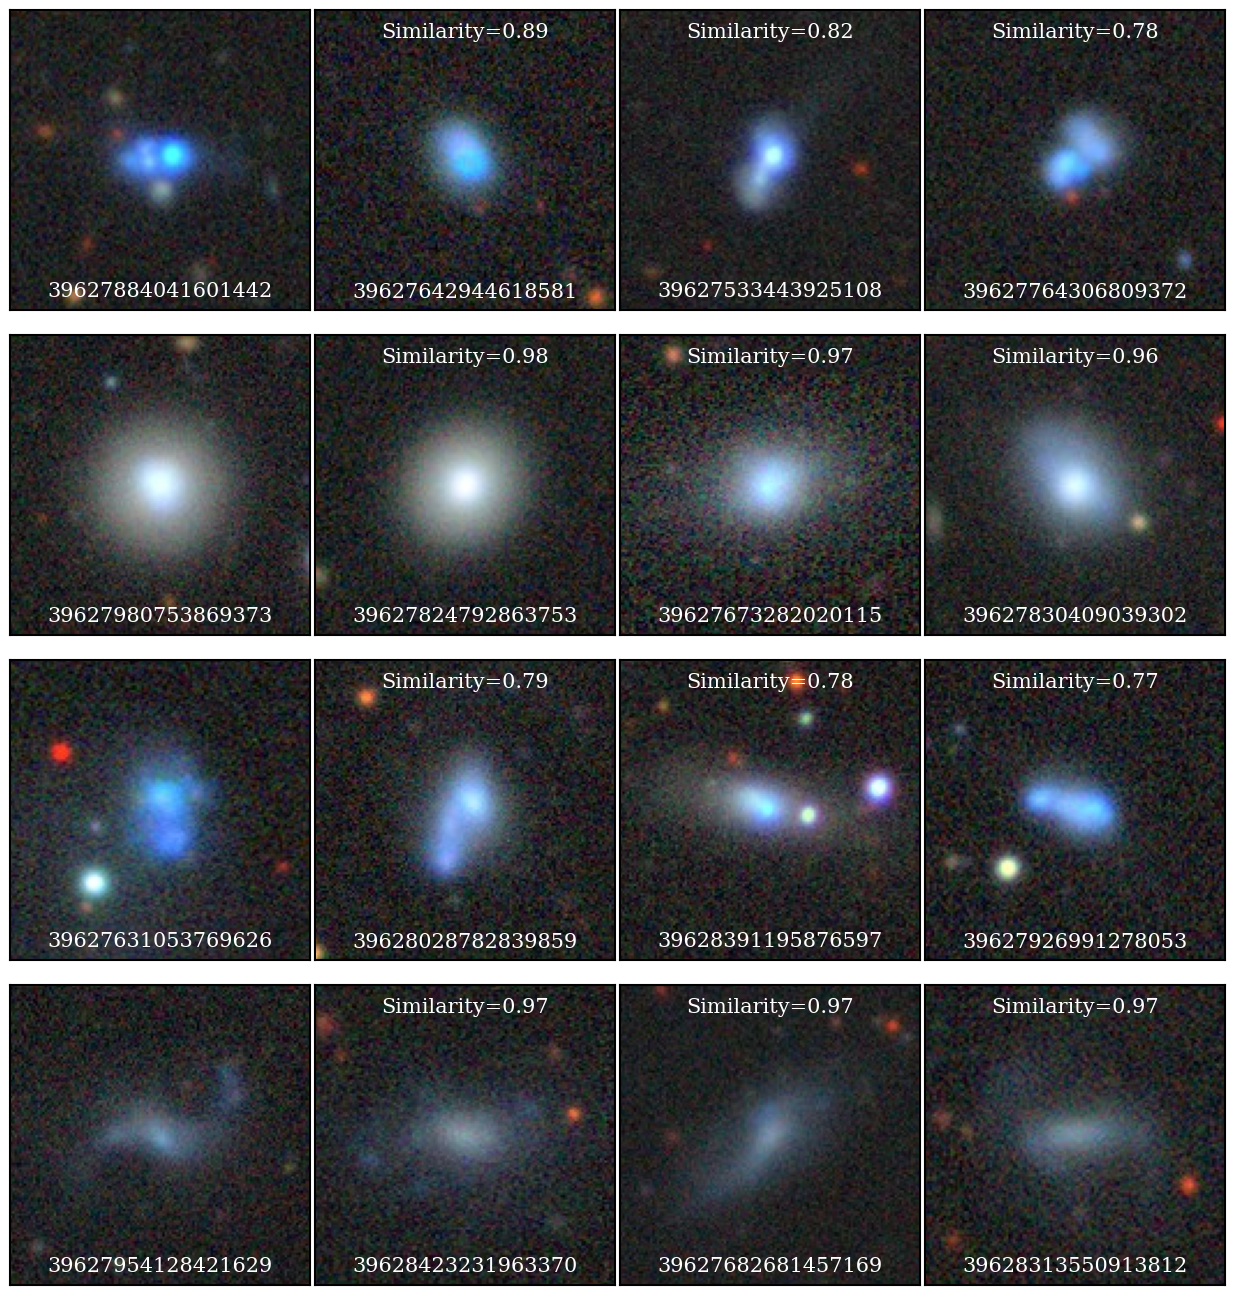

In [830]:
## make a plot with in a single column of examples
save_path = "/pscratch/sd/v/virajvm/trash/desi_imgs_sims"

image_size_sim = 130

fig, ax = make_subplots(ncol=4,nrow=4,return_fig=True,row_spacing=0.25,col_spacing=0.05)

for eg_idx, tgid_eg_i in enumerate(tgids_eg):
    tgids_sim_i, ras, decs, sim_scores_i = get_top3_sim(tgid_eg_i)
    #looping over all the targetids we need to plot
    for i,tid in enumerate(tgids_sim_i):
        
        img_path = save_path + f"/img_{tid}.jpg"
        #check if img exists first
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
        else:
            save_jpg(ras[i],decs[i],img_path,session, size=image_size_sim)
            
            img = mpimg.imread(img_path)
        
        ax[i + 4*eg_idx].imshow(img,rasterized=True)
        ax[i + 4*eg_idx].text(0.5,0.06,tid,transform=ax[i+4*eg_idx].transAxes,fontsize=15,color="white",ha="center",va="center")

        # if i == 0:
        #     for spine in ax[i + 4*eg_idx].spines.values():
        #         spine.set_edgecolor("indianred")
        #         spine.set_linewidth(5)
                    
        if i > 0:
            ax[i + 4*eg_idx].text(0.5,0.925,f"Similarity={sim_scores_i[i]:.2f}",
                                  transform=ax[i+4*eg_idx].transAxes,fontsize=15,color="white",ha="center",va="center")
        
for axi in ax:
    axi.set_xticks([])
    axi.set_yticks([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_similarity_grid.pdf",bbox_inches="tight")

##39627977893351426  once i make the targets unique, this is also a good one to choose!!!

plt.show()
